In [171]:
import pandas as pd

In [172]:
import numpy as np

In [173]:
import warnings
import plotnine as pln
from plotnine.exceptions import PlotnineWarning

warnings.filterwarnings("ignore", category=PlotnineWarning)

In [174]:
df_tashpa = pd.read_excel(f"C:\\Users\\idowe\\MyProjects\\בקשות להיתר 2024-2026.xlsx", sheet_name='תשפ"ה')
df_tashpav = pd.read_excel(f"C:\\Users\\idowe\\MyProjects\\בקשות להיתר 2024-2026.xlsx", sheet_name='תשפ"ו')

C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
C:\Users\idowe\AppData\Local\Programs\Python\Python314\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed


# Data cleaning

requests over 120 days = outliers

In [175]:
import pandas as pd

def clean_dataframe(df, max_days=120):
    # 1. איתור דינמי של עמודת משך הטיפול
    duration_cols = [c for c in df.columns if 'משך' in c or 'ימים' in c]
    if not duration_cols:
        print("אזהרה: לא נמצאה עמודת משך טיפול. ה-DataFrame הוחזר ללא שינוי.")
        return df
    
    col_duration = duration_cols[0]
    
    # 2. יצירת עותק והמרת העמודה למספר (במקרה שיש מחרוזות או ערכים חסרים)
    df_clean = df.copy()
    df_clean[col_duration] = pd.to_numeric(df_clean[col_duration], errors='coerce')
    
    # 3. סינון שורות: השארת רק בקשות שמשך הטיפול שלהן קטן או שווה ל-120 ימים
    initial_count = len(df_clean)
    df_filtered = df_clean[df_clean[col_duration] <= max_days].copy()
    removed_count = initial_count - len(df_filtered)
    
    print(f"סנן בהצלחה: הוסרו {removed_count} חריגות (מעל {max_days} ימים). נותרו {len(df_filtered)} שורות.")
    
    return df_filtered

# הפעלה בתחילת הקובץ לפני שאר הניתוחים:
df_tashpa = clean_dataframe(df_tashpa)
df_tashpav = clean_dataframe(df_tashpav)

סנן בהצלחה: הוסרו 55 חריגות (מעל 120 ימים). נותרו 590 שורות.
סנן בהצלחה: הוסרו 72 חריגות (מעל 120 ימים). נותרו 557 שורות.


# EDA

## Requests segmentation per year

In [176]:
print(len(df_tashpa))
print(len(df_tashpav))

590
557


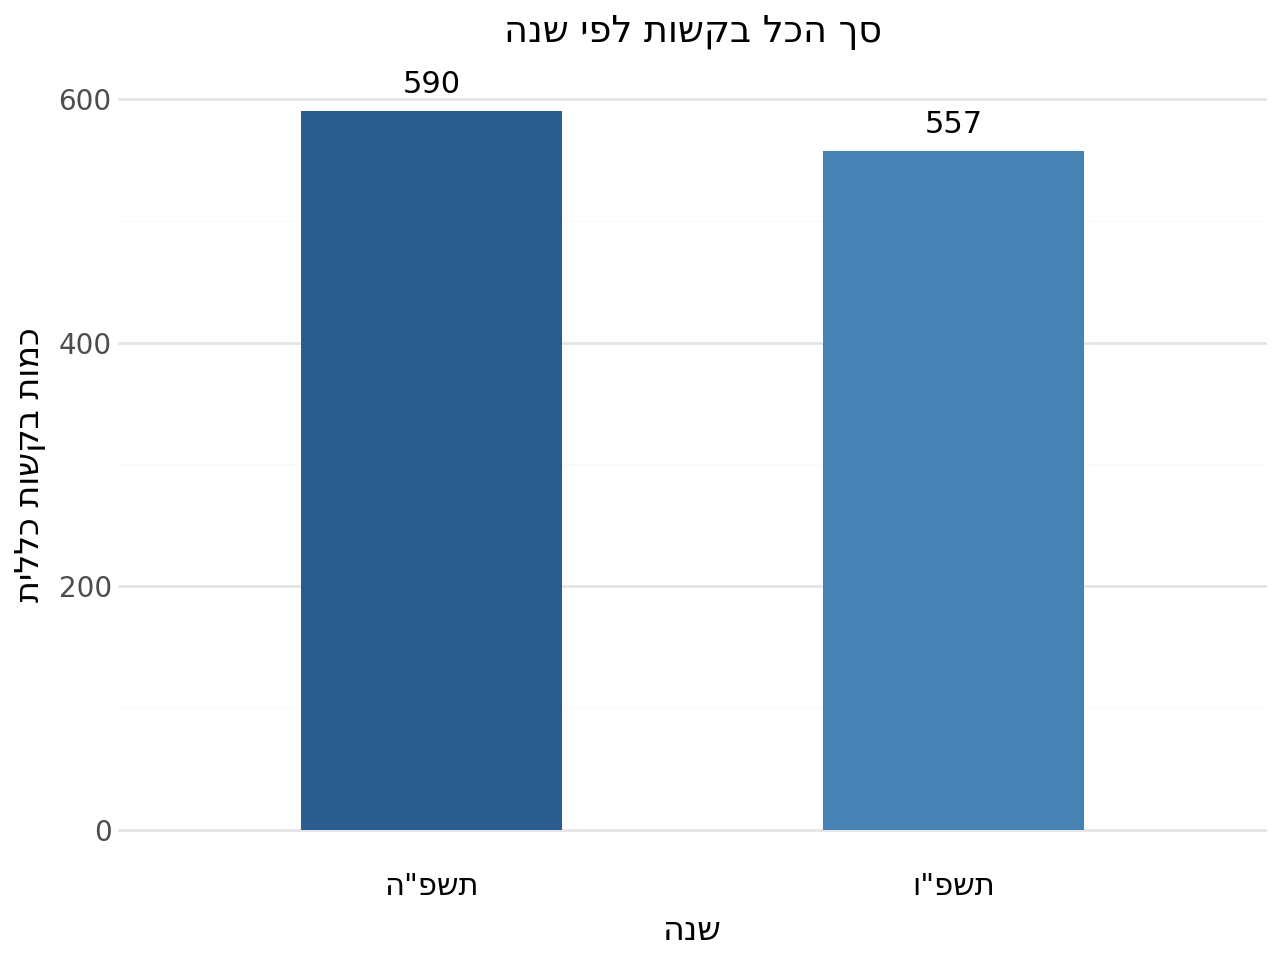

In [177]:
import plotnine as pln
from bidi.algorithm import get_display
import arabic_reshaper

fix_text = lambda t: get_display(arabic_reshaper.reshape(str(t)))

# 1. יצירת DataFrame מסכם
summary_df = pd.DataFrame({
    'שנה': [fix_text('תשפ"ה'), fix_text('תשפ"ו')],
    'כמות': [len(df_tashpa), len(df_tashpav)]
})

# 2. בניית הדיאגרמה המתוקנת
chart_total = (
    pln.ggplot(summary_df, pln.aes(x='שנה', y='כמות', fill='שנה'))
    + pln.geom_col(width=0.5, show_legend=False)
    + pln.geom_text(pln.aes(label='כמות'), va='bottom', nudge_y=10) # תיקון: nudge_y כפרמטר ישיר
    + pln.scale_fill_manual(values=['#2B5C8F', '#4682B4'])
    + pln.labs(
        x=fix_text('שנה'),
        y=fix_text('כמות בקשות כללית'),
        title=fix_text('סך הכל בקשות לפי שנה')
    )
    + pln.theme_minimal()
    + pln.theme(
        text=pln.element_text(family='sans-serif'),
        axis_text_x=pln.element_text(size=11, color='black'),
        axis_text_y=pln.element_text(size=10),
        axis_title=pln.element_text(size=12),
        panel_grid_major_x=pln.element_blank()
    )
)

display(chart_total)

## Request segmentation per researcher

Tashphav - Request segmentation per researcher

In [178]:
print(df_tashpav['שם הפונה'].value_counts())

שם הפונה
בתיה צור             10
סווטה פיכמן           7
ורד גוטדינר           6
יובל אופק             6
גיאנא חליפה           6
                     ..
רועי פרלשטייןדביר     1
רעות רוזנבלט          1
ליאת כהן              1
קלרינה פריבורקין      1
ליאת שטיינדל          1
Name: count, Length: 393, dtype: int64


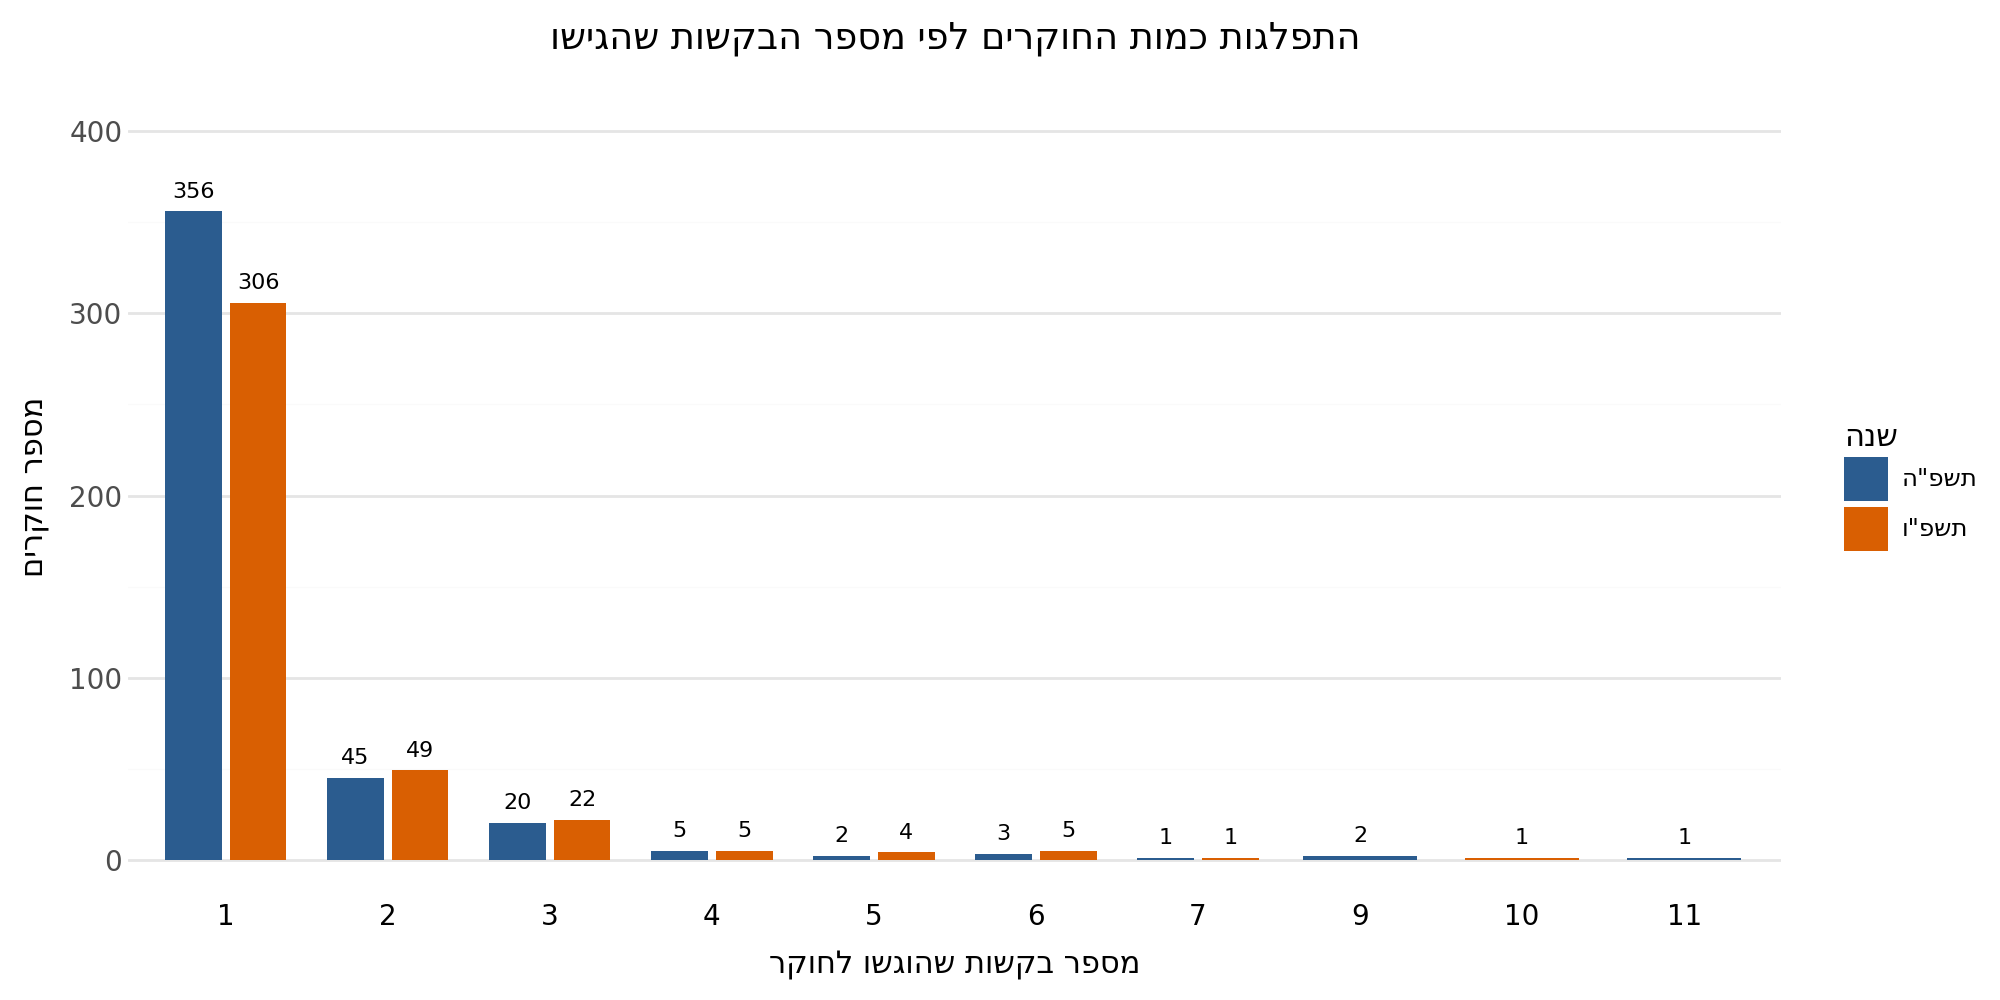

In [179]:
fix_text = lambda t: get_display(arabic_reshaper.reshape(str(t)))

# איתור דינמי של עמודת שם הפונה/חוקר
col_researcher = [c for c in df_tashpa.columns if 'פונה' in c or 'חוקר' in c][0]

# 1. חישוב מספר הבקשות לכל חוקר בכל שנה
counts_tashpa = df_tashpa[col_researcher].value_counts().reset_index()
counts_tashpa.columns = [col_researcher, 'מספר_בקשות']
counts_tashpa['שנה'] = 'תשפ"ה'

counts_tashpav = df_tashpav[col_researcher].value_counts().reset_index()
counts_tashpav.columns = [col_researcher, 'מספר_בקשות']
counts_tashpav['שנה'] = 'תשפ"ו'

df_researchers = pd.concat([counts_tashpa, counts_tashpav], ignore_index=True)

# 2. חישוב כמות החוקרים עבור כל סכום בקשות
df_hist = (
    df_researchers.groupby(['שנה', 'מספר_בקשות'])
    .size()
    .reset_index(name='כמות_חוקרים')
)

# 3. תיקון מיון ציר X
unique_counts = sorted(df_hist['מספר_בקשות'].unique())
df_hist['מספר_בקשות_cat'] = pd.Categorical(
    df_hist['מספר_בקשות'].astype(str),
    categories=[str(x) for x in unique_counts],
    ordered=True
)

# 4. יצירת עמודת מיקום אנכי ייעודית למניעת התנגשות עם position_dodge
max_val = df_hist['כמות_חוקרים'].max()
df_hist['y_text'] = df_hist['כמות_חוקרים'] + (max_val * 0.015)

# עיבוד עברית
df_hist['שנה_fix'] = df_hist['שנה'].apply(fix_text)

year_colors = {
    fix_text('תשפ"ה'): '#2B5C8F',
    fix_text('תשפ"ו'): '#D95F02'
}

max_y = max_val * 1.15

# 5. בניית התרשים המתוקן
chart_researcher_dist = (
    pln.ggplot(df_hist, pln.aes(x='מספר_בקשות_cat', y='כמות_חוקרים', fill='שנה_fix'))
    + pln.geom_col(position=pln.position_dodge(width=0.8), width=0.7)
    + pln.geom_text(
        pln.aes(y='y_text', label='כמות_חוקרים', group='שנה_fix'),
        position=pln.position_dodge(width=0.8),
        va='bottom',
        size=8
    )
    + pln.ylim(0, max_y)
    + pln.scale_fill_manual(values=year_colors)
    + pln.labs(
        x=fix_text('מספר בקשות שהוגשו לחוקר'),
        y=fix_text('מספר חוקרים'),
        fill=fix_text('שנה'),
        title=fix_text('התפלגות כמות החוקרים לפי מספר הבקשות שהגישו')
    )
    + pln.theme_minimal()
    + pln.theme(
        text=pln.element_text(family='sans-serif'),
        axis_text_x=pln.element_text(size=10, color='black'),
        axis_text_y=pln.element_text(size=10),
        axis_title=pln.element_text(size=11),
        panel_grid_major_x=pln.element_blank(),
        figure_size=(10, 5)
    )
)

chart_researcher_dist

Tashpha - Request segmentation per researcher

In [180]:
print(df_tashpa['שם הפונה'].value_counts())

שם הפונה
תחיה וינוגרדגאן       11
מיכל שרייבר            9
בתיה צור               9
שרון קפלןברקלי         7
עמליה שחף              6
                      ..
נאילה תלס מחאגנה       1
ענבל קולושי-מינסקר     1
כרים נסר               1
דנה מאיר               1
כרמית פריש             1
Name: count, Length: 435, dtype: int64


## Requests per path ( Green \ Red)

In [181]:
print(df_tashpa['מסלול'].value_counts())
print(df_tashpav['מסלול'].value_counts())


מסלול
אדום    386
ירוק    204
Name: count, dtype: int64
מסלול
אדום    340
ירוק    217
Name: count, dtype: int64


In [182]:
counts_tashpa = df_tashpa['מסלול'].value_counts()
counts_tashpav = df_tashpav['מסלול'].value_counts()

tashpa_red = counts_tashpa['אדום']      # 413
tashpa_green = counts_tashpa['ירוק']    # 231

tashpav_red = counts_tashpav['אדום']    # 385
tashpav_green = counts_tashpav['ירוק']  # 244

In [183]:
# הוספת עמודת מזהה שנה לכל דאטה פריים
df_tashpa['שנה'] = 'תשפ"ה'
df_tashpav['שנה'] = 'תשפ"ו'

# איחוד לשני ה-DataFrames לכדי DataFrame אחד
df_combined = pd.concat([df_tashpa, df_tashpav])

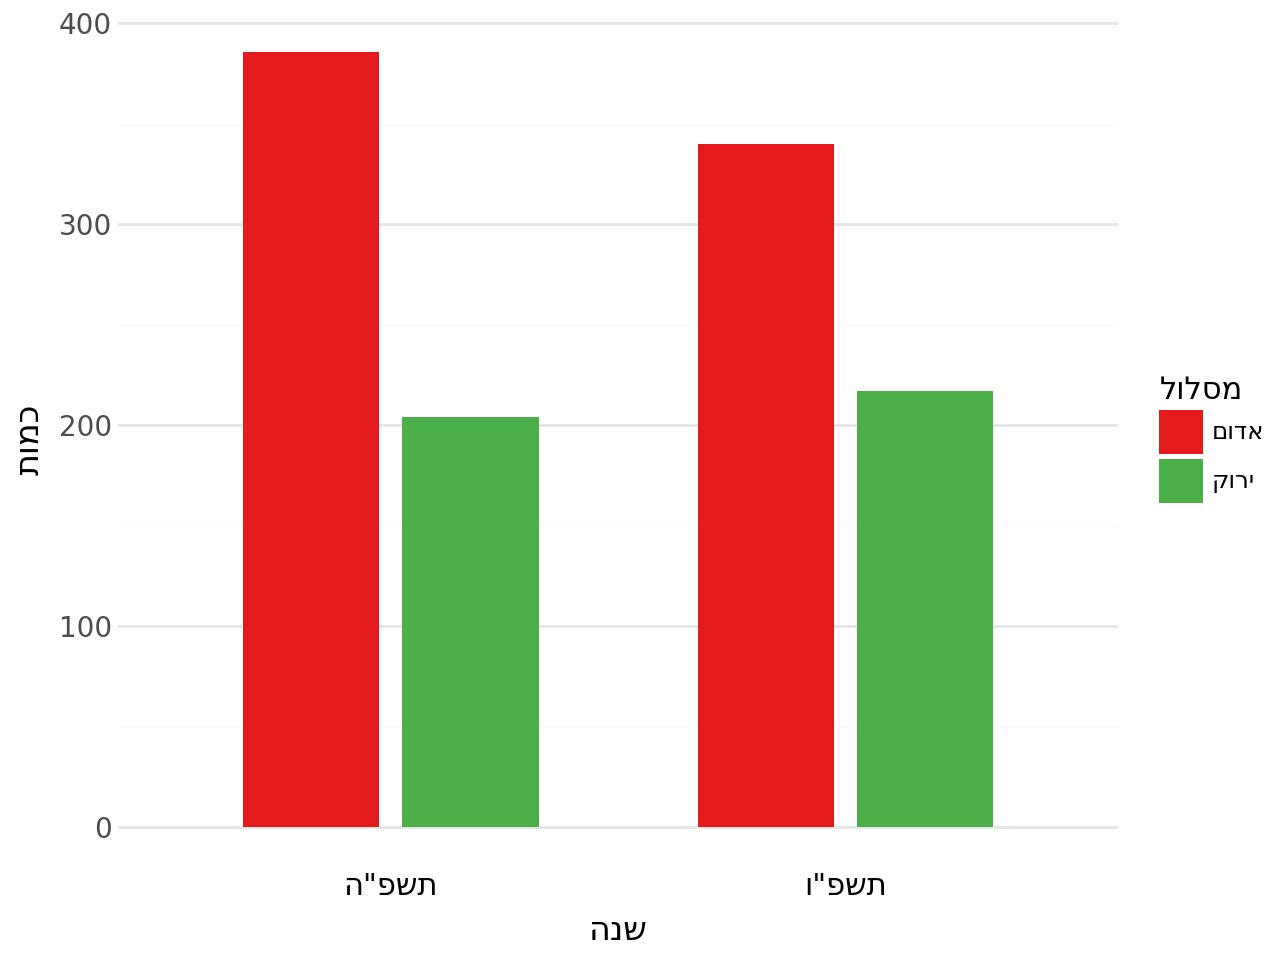

In [184]:
import pandas as pd
import plotnine as pln
from bidi.algorithm import get_display
import arabic_reshaper

# 1. פונקציית תיקון בטוחה המטפלת גם בערכים שאינם מחרוזת
def fix_text(val):
    if pd.isna(val):
        return val
    return get_display(arabic_reshaper.reshape(str(val)))

# 2. ניקוי ויצירת עמודות מתוקנות ב-DataFrame
df_clean = df_combined.dropna(subset=['מסלול']).copy()
df_clean['שנה_fix'] = df_clean['שנה'].apply(fix_text)
df_clean['מסלול_fix'] = df_clean['מסלול'].apply(fix_text)

# 3. מיפוי הצבעים לפי הערכים המתוקנים
color_map = {
    fix_text('אדום'): '#E41A1C',
    fix_text('ירוק'): '#4DAF4A'
}

# 4. בניית הגרף
chart_fixed = (
    pln.ggplot(df_clean, pln.aes(x='שנה_fix', fill='מסלול_fix'))
    + pln.geom_bar(position=pln.position_dodge(width=0.7), width=0.6)
    + pln.scale_fill_manual(values=color_map)
    + pln.labs(
        x=fix_text('שנה'),
        y=fix_text('כמות'),
        fill=fix_text('מסלול')
    )
    + pln.theme_minimal()
    + pln.theme(
        text=pln.element_text(family='sans-serif'),
        axis_text_x=pln.element_text(size=11, color='black'),
        axis_text_y=pln.element_text(size=10),
        axis_title=pln.element_text(size=12),
        panel_grid_major_x=pln.element_blank()
    )
)

display(chart_fixed)

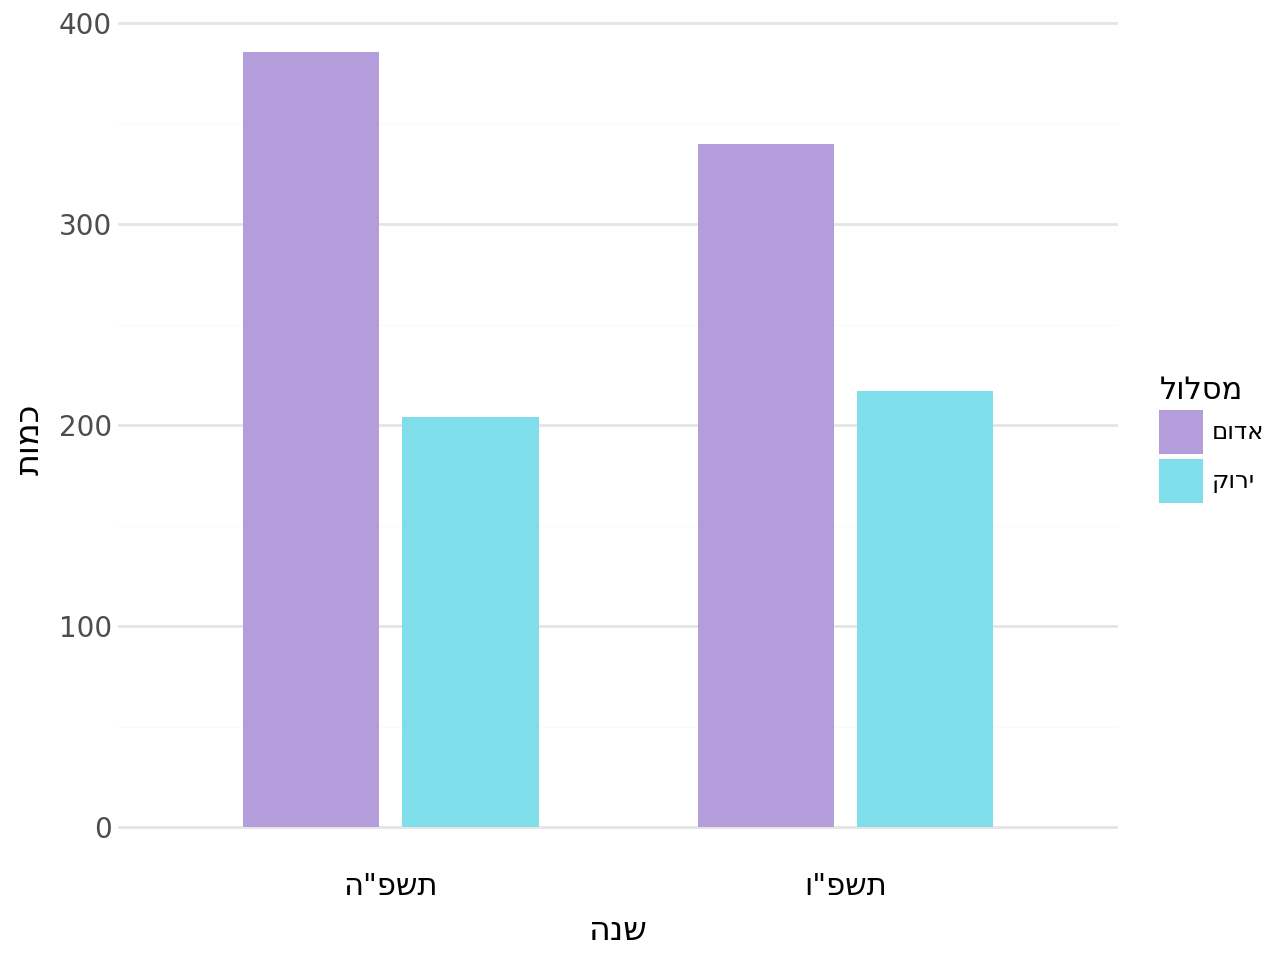

In [185]:
# 1. Text correction function for RTL Hebrew formatting (Bidi + Reshaper)
def fix_text(val):
    if pd.isna(val):
        return val
    return get_display(arabic_reshaper.reshape(str(val)))

# 2. Clean data, prepare columns, and round numerical values to 1 decimal place
df_clean = df_combined.dropna(subset=['מסלול']).copy()

# Round all float columns to 1 decimal place
num_cols = df_clean.select_dtypes(include=['float', 'float64']).columns
df_clean[num_cols] = df_clean[num_cols].round(1)

df_clean['שנה_fix'] = df_clean['שנה'].apply(fix_text)
df_clean['מסלול_fix'] = df_clean['מסלול'].apply(fix_text)

# 3. Accessible color mapping using Chief Scientist Office palette (Lilac Purple & Teal)
color_map = {
    fix_text('אדום'): '#B39DDB',   # Lilac Purple
    fix_text('ירוק'): '#80DEEA'    # Teal / Turquoise
}

# 4. Construct the plot
chart_fixed = (
    pln.ggplot(df_clean, pln.aes(x='שנה_fix', fill='מסלול_fix'))
    + pln.geom_bar(position=pln.position_dodge(width=0.7), width=0.6)
    + pln.scale_fill_manual(values=color_map)
    + pln.labs(
        x=fix_text('שנה'),
        y=fix_text('כמות'),
        fill=fix_text('מסלול')
    )
    + pln.theme_minimal()
    + pln.theme(
        text=pln.element_text(family='sans-serif'),
        axis_text_x=pln.element_text(size=11, color='black'),
        axis_text_y=pln.element_text(size=10),
        axis_title=pln.element_text(size=12),
        panel_grid_major_x=pln.element_blank(),

        # Uncomment the line below to add a subtle border around the plot panel:
        # panel_border=pln.element_rect(color='#E0E0E0', size=0.5)
    )
)

display(chart_fixed)

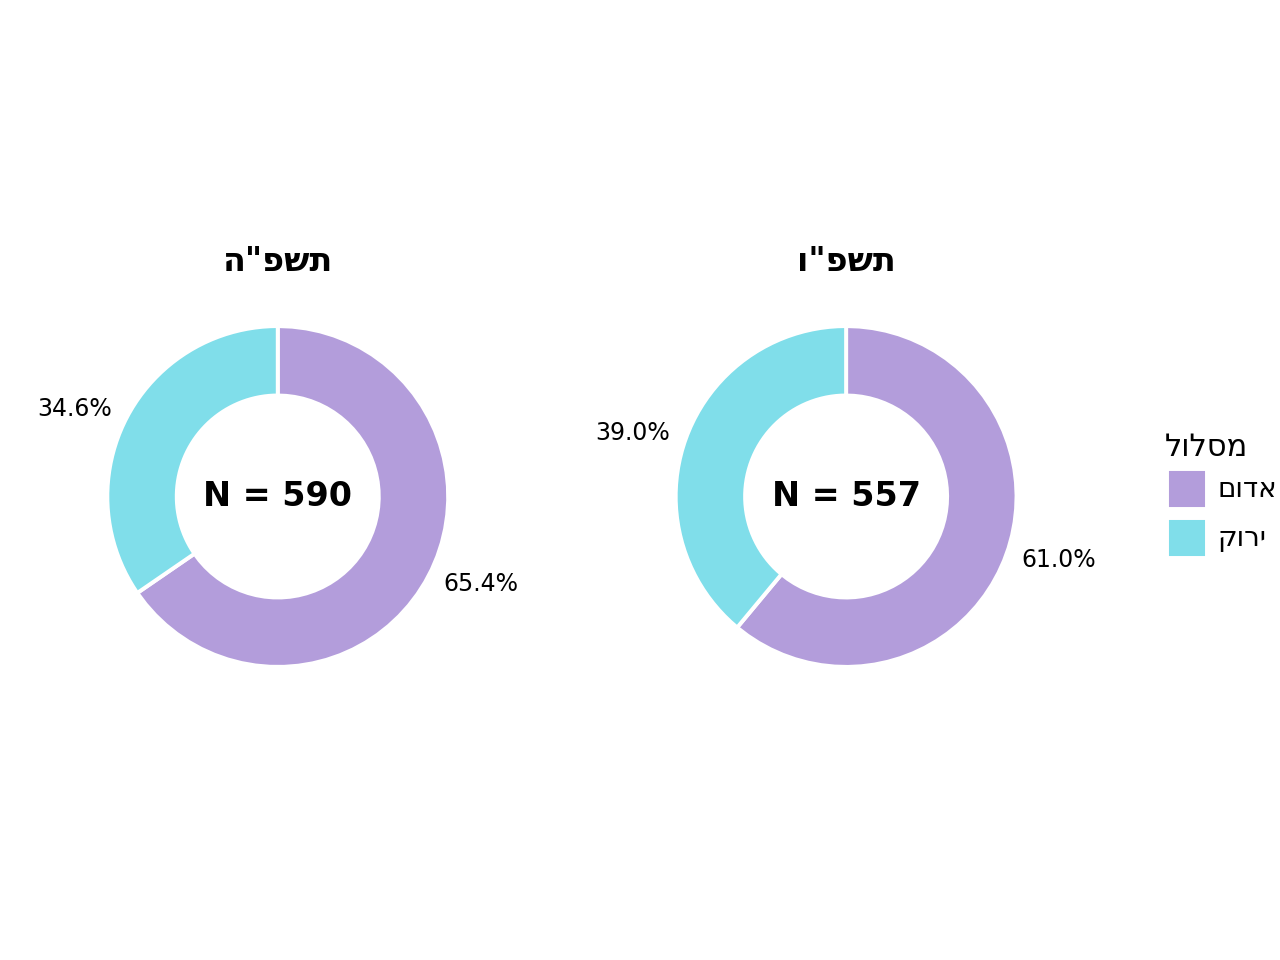

In [195]:
import numpy as np
import pandas as pd
import plotnine as pln
from bidi.algorithm import get_display
import arabic_reshaper

# 1. Text correction function for RTL Hebrew formatting
def fix_text(val):
    if pd.isna(val):
        return val
    return get_display(arabic_reshaper.reshape(str(val)))

# 2. Data preparation and cleaning
df_clean = df_combined.dropna(subset=['מסלול']).copy()
df_clean['שנה_fix'] = df_clean['שנה'].apply(fix_text)
df_clean['מסלול_fix'] = df_clean['מסלול'].apply(fix_text)

df_counts = df_clean.groupby(['שנה_fix', 'מסלול_fix']).size().reset_index(name='count')

# 3. Geometry function with enlarged donut radii (r_in=0.80, r_out=1.35)
def create_donut_geometry(df, r_in=0.80, r_out=1.35, n_points=50):
    poly_list, label_list, center_list = [], [], []

    for year, group in df.groupby('שנה_fix'):
        total_n = group['count'].sum()

        # Center N text
        center_list.append({
            'שנה_fix': year,
            'x': 0, 'y': 0,
            'label': f'N = {total_n}'
        })

        current_angle = np.pi / 2  # Start angle at top (12 o'clock)

        for _, row in group.iterrows():
            cat = row['מסלול_fix']
            cnt = row['count']
            frac = cnt / total_n
            pct = frac * 100

            angle_span = 2 * np.pi * frac
            end_angle = current_angle - angle_span

            # Slice polygon arcs
            angles_out = np.linspace(current_angle, end_angle, n_points)
            angles_in = np.linspace(end_angle, current_angle, n_points)

            xs = np.concatenate([r_out * np.cos(angles_out), r_in * np.cos(angles_in)])
            ys = np.concatenate([r_out * np.sin(angles_out), r_in * np.sin(angles_in)])

            for x, y in zip(xs, ys):
                poly_list.append({
                    'שנה_fix': year,
                    'מסלול_fix': cat,
                    'x': x, 'y': y,
                    'group_id': f"{year}_{cat}"
                })

            # Position percentage text labels just outside the donut ring (no arrows)
            mid_angle = current_angle - (angle_span / 2)
            r_text = 1.48

            x_dir = np.cos(mid_angle)
            hjust_val = 'left' if x_dir >= 0 else 'right'

            label_list.append({
                'שנה_fix': year,
                'מסלול_fix': cat,
                'x_text': r_text * np.cos(mid_angle),
                'y_text': r_text * np.sin(mid_angle),
                'hjust': hjust_val,
                'label': f"{pct:.1f}%"
            })

            current_angle = end_angle

    return pd.DataFrame(poly_list), pd.DataFrame(label_list), pd.DataFrame(center_list)

df_poly, df_labels, df_center = create_donut_geometry(df_counts)

# 4. Color map (Soft Lilac Purple & Soft Teal)
color_map = {
    fix_text('אדום'): '#B39DDB',   # Soft Lilac Purple
    fix_text('ירוק'): '#80DEEA'    # Soft Teal
}

# 5. Clean chart layout without arrows
donut_chart = (
    pln.ggplot()
    # Donut slices
    + pln.geom_polygon(
        df_poly,
        pln.aes(x='x', y='y', fill='מסלול_fix', group='group_id'),
        color='white', size=0.8
    )
    # Percentage text labels
    + pln.geom_text(
        df_labels,
        pln.aes(x='x_text', y='y_text', label='label', hjust='hjust'),
        size=8.5, color='black'
    )
    # Total N in center
    + pln.geom_text(
        df_center,
        pln.aes(x='x', y='y', label='label'),
        size=12, fontweight='bold', color='black'
    )
    + pln.facet_wrap('~שנה_fix')
    + pln.scale_fill_manual(values=color_map)
    + pln.coord_equal()
    # Canvas boundaries
    + pln.xlim(-2.0, 2.0)
    + pln.ylim(-1.6, 1.6)
    + pln.labs(fill=fix_text('מסלול'), x='', y='')
    + pln.theme_void()
    + pln.theme(
        text=pln.element_text(family='sans-serif'),
        strip_text=pln.element_text(size=12, fontweight='bold', color='black'),
        legend_title=pln.element_text(size=11),
        legend_text=pln.element_text(size=10),

        # Remove axis elements
        axis_text_x=pln.element_blank(),
        axis_text_y=pln.element_blank(),
        axis_title_x=pln.element_blank(),
        axis_title_y=pln.element_blank(),
        axis_ticks=pln.element_blank(),
        axis_line=pln.element_blank(),

        plot_background=pln.element_rect(fill='white', color='white'),
        panel_background=pln.element_rect(fill='white')
    )
)

display(donut_chart)

## Request's treatment time

In [ ]:
tashpa_red_df = df_tashpa[df_tashpa['מסלול'] == 'אדום'][['מסלול', 'ימים משליחת הבקשה']]
print(len(tashpa_red_df))

red_avg_days = tashpa_red_df['ימים משליחת הבקשה'].mean()
print(f"משך הזמן הממוצע לטיפול במסלול אדום בתשפה הוא:{red_avg_days}")

In [ ]:
tashpa_green_df = df_tashpa[df_tashpa['מסלול'] == 'ירוק'][['מסלול', 'ימים משליחת הבקשה']]
print(len(tashpa_green_df))

green_avg_days = tashpa_green_df['ימים משליחת הבקשה'].mean()
print(f"משך הזמן הממוצע לטיפול במסלול ירוק בתשפה הוא:{green_avg_days}")

In [ ]:
tashpav_red_df = df_tashpav[df_tashpav['מסלול'] == 'אדום'][['מסלול', 'ימים משליחת הבקשה']]
print(len(tashpav_red_df))

red_avg_days = tashpav_red_df['ימים משליחת הבקשה'].mean()
print(f"משך הזמן הממוצע לטיפול במסלול אדום בתשפו הוא:{red_avg_days}")

In [ ]:
tashpav_green_df = df_tashpav[df_tashpav['מסלול'] == 'ירוק'][['מסלול', 'ימים משליחת הבקשה']]
print(len(tashpav_green_df))

green_avg_days = tashpav_green_df['ימים משליחת הבקשה'].mean()
print(f"משך הזמן הממוצע לטיפול במסלול ירוק בתשפו הוא:{green_avg_days}")

In [ ]:
import pandas as pd
import plotnine as pln
from bidi.algorithm import get_display
import arabic_reshaper

# פונקציית הטיפול בטקסט עברי
def fix_text(val):
    if pd.isna(val):
        return val
    return get_display(arabic_reshaper.reshape(str(val)))

# 1. הגדרת השנה לכל DataFrame ואיחוד
df_tashpa_copy = df_tashpa.copy()
df_tashpa_copy['שנה'] = 'תשפ"ה'

df_tashpav_copy = df_tashpav.copy()
df_tashpav_copy['שנה'] = 'תשפ"ו'

df_all = pd.concat([df_tashpa_copy, df_tashpav_copy], ignore_index=True)

# 2. חישוב ממוצע ימי הטיפול לפי שנה ומסלול
df_avg = (
    df_all.dropna(subset=['מסלול', 'ימים משליחת הבקשה'])
    .groupby(['שנה', 'מסלול'], as_index=False)['ימים משליחת הבקשה']
    .mean()
)

# ניקוד עשרוני מוגבל ל-1 לנוחות הצגה
df_avg['ממוצע_עגול'] = df_avg['ימים משליחת הבקשה'].round(1)

# 3. עיבוד עברית מראש
df_avg['שנה_fix'] = df_avg['שנה'].apply(fix_text)
df_avg['מסלול_fix'] = df_avg['מסלול'].apply(fix_text)

color_map = {
    fix_text('אדום'): '#E41A1C',
    fix_text('ירוק'): '#4DAF4A'
}

# 4. בניית הדיאגרמה
chart_duration = (
    pln.ggplot(df_avg, pln.aes(x='שנה_fix', y='ימים משליחת הבקשה', fill='מסלול_fix'))
    + pln.geom_col(position=pln.position_dodge(width=0.7), width=0.6)
    + pln.geom_text(
        pln.aes(label='ממוצע_עגול'),
        position=pln.position_dodge(width=0.7),
        va='bottom',
        size=9
    )
    + pln.scale_fill_manual(values=color_map)
    + pln.labs(
        x=fix_text('שנה'),
        y=fix_text('ממוצע ימי טיפול'),
        fill=fix_text('מסלול'),
        title=fix_text('משך טיפול ממוצע בימים לפי מסלול ושנה')
    )
    + pln.theme_minimal()
    + pln.theme(
        text=pln.element_text(family='sans-serif'),
        axis_text_x=pln.element_text(size=11, color='black'),
        axis_text_y=pln.element_text(size=10),
        axis_title=pln.element_text(size=12),
        panel_grid_major_x=pln.element_blank()
    )
)

chart_duration

## Segmentaion per SE

In [ ]:
target_categories = ['מסלול', 'האם בין הנבדקים במחקר גם תלמידי חינוך מיוחד?']

tashpa_special_edu_df = df_tashpa[
    (df_tashpa['מסלול'] == 'אדום') & 
    (df_tashpa['האם בין הנבדקים במחקר גם תלמידי חינוך מיוחד?'] == 'כן')
][target_categories]

tashpa_special_edu_df.head()

In [ ]:
print(len(tashpa_special_edu_df))

In [ ]:
target_categories = ['מסלול', 'האם בין הנבדקים במחקר גם תלמידי חינוך מיוחד?']

tashpav_special_edu_df = df_tashpav[
    (df_tashpav['מסלול'] == 'אדום') & 
    (df_tashpav['האם בין הנבדקים במחקר גם תלמידי חינוך מיוחד?'] == 'כן')
][target_categories]

tashpa_special_edu_df.head()

In [ ]:
print(len(tashpav_special_edu_df))

In [ ]:
fix_text = lambda t: get_display(arabic_reshaper.reshape(str(t)))
col_special = 'האם בין הנבדקים במחקר גם תלמידי חינוך מיוחד?'

# 1. חישוב נתונים עבור תשפ"ה
red_tashpa = df_tashpa[df_tashpa['מסלול'] == 'אדום']
count_tashpa = len(red_tashpa[red_tashpa[col_special] == 'כן'])
total_tashpa = len(red_tashpa)
pct_tashpa = (count_tashpa / total_tashpa) * 100

# 2. חישוב נתונים עבור תשפ"ו
red_tashpav = df_tashpav[df_tashpav['מסלול'] == 'אדום']
count_tashpav = len(red_tashpav[red_tashpav[col_special] == 'כן'])
total_tashpav = len(red_tashpav)
pct_tashpav = (count_tashpav / total_tashpav) * 100

# 3. יצירת DataFrame מסכם
df_pct = pd.DataFrame({
    'שנה': ['תשפ"ה', 'תשפ"ו'],
    'אחוז': [pct_tashpa, pct_tashpav],
    'כמות': [count_tashpa, count_tashpav],
    'סהכ': [total_tashpa, total_tashpav]
})

df_pct['שנה_fix'] = df_pct['שנה'].apply(fix_text)

# יצירת תווית מורכבת בת שתי שורות
df_pct['תווית'] = df_pct.apply(
    lambda r: f"{r['אחוז']:.1f}%\n({r['כמות']}/{r['סהכ']})", 
    axis=1
)

# 4. בניית הדיאגרמה המתוקנת
chart_special_edu = (
    pln.ggplot(df_pct, pln.aes(x='שנה_fix', y='אחוז', fill='שנה_fix'))
    + pln.geom_col(width=0.5, show_legend=False)
    + pln.geom_text(
        pln.aes(label='תווית'), 
        va='bottom', 
        nudge_y=0.8,
        size=9.5
    )
    + pln.ylim(0, 36) # פתרון החיתוך: הרחבת גבול ציר Y כדי לתת מקום לטקסט
    + pln.scale_fill_manual(values=['#E41A1C', '#B30000'])
    + pln.labs(
        x=fix_text('שנה'),
        y=fix_text('שיעור הבקשות (%)'),
        title=fix_text('שיעור הכללת חינוך מיוחד במסלול האדום')
    )
    + pln.theme_minimal()
    + pln.theme(
        text=pln.element_text(family='sans-serif'),
        axis_text_x=pln.element_text(size=11, color='black'),
        axis_text_y=pln.element_text(size=10),
        axis_title=pln.element_text(size=12),
        panel_grid_major_x=pln.element_blank()
    )
)

chart_special_edu

## Segmentation per intervention plan

In [ ]:
interventions_tashpa = df_tashpa['האם המחקר בוחן תכנית התערבות?'].value_counts()
print(interventions_tashpa)


In [ ]:
interventions_tashpav = df_tashpav['האם המחקר בוחן תכנית התערבות?'].value_counts()
print(interventions_tashpav)

In [ ]:
fix_text = lambda t: get_display(arabic_reshaper.reshape(str(t)))

# איתור דינמי של שם העמודה למניעת בעיות תווים
col_interventions = [c for c in df_tashpa.columns if 'האם המחקר בוחן תכנית התערבות' in c][0]

# 1. איחוד הנתונים מ-2 השנים
df_tashpa_sub = df_tashpa[[col_interventions]].dropna().assign(שנה='תשפ"ה')
df_tashpav_sub = df_tashpav[[col_interventions]].dropna().assign(שנה='תשפ"ו')
df_combined = pd.concat([df_tashpa_sub, df_tashpav_sub], ignore_index=True)

# 2. חישוב כמויות לפי שנה וסוג התערבות
df_counts = (
    df_combined.groupby(['שנה', col_interventions])
    .size()
    .reset_index(name='כמות')
)

# 3. ניסוח מקוצר לתוויות המקרא
label_mapping = {
    'המחקר לא בוחן תכנית התערבות': 'לא בוחן תכנית התערבות',
    'כן, המחקר בוחן תכנית שתופעל במסגרת החינוכית כחלק מן המחקר': 'תכנית כחלק מן המחקר',
    'כן, המחקר בוחן תכנית המופעלת במסגרת החינוכית, ללא קשר למחקר': 'תכנית ללא קשר למחקר'
}

df_counts['קטגוריה'] = df_counts[col_interventions].map(label_mapping).fillna(df_counts[col_interventions])

# 4. עיבוד עברית
df_counts['קטגוריה_fix'] = df_counts['קטגוריה'].apply(fix_text)
df_counts['שנה_fix'] = df_counts['שנה'].apply(fix_text)

# 5. הגדרת גבול Y למניעת חיתוך בחלק העליון
max_y = df_counts['כמות'].max() * 1.18

# 6. בניית הדיאגרמה
chart_interventions = (
    pln.ggplot(df_counts, pln.aes(x='שנה_fix', y='כמות', fill='קטגוריה_fix'))
    + pln.geom_col(position=pln.position_dodge(width=0.8), width=0.7)
    + pln.geom_text(
        pln.aes(label='כמות'),
        position=pln.position_dodge(width=0.8),
        va='bottom',
        nudge_y=8,  # הרמת המספרים מעל ראש העמודות
        size=9.5
    )
    + pln.ylim(0, max_y)
    + pln.scale_fill_brewer(type='qual', palette='Set2')
    + pln.labs(
        x=fix_text('שנה'),
        y=fix_text('מספר מחקרים'),
        fill=fix_text('סוג התערבות'),
        title=fix_text('השוואת תכניות התערבות לפי שנה')
    )
    + pln.theme_minimal()
    + pln.theme(
        text=pln.element_text(family='sans-serif'),
        axis_text_x=pln.element_text(size=10, color='black', angle=45, ha='right'),  # הטיית טקסט ב-45 מעלות
        axis_text_y=pln.element_text(size=10),
        axis_title=pln.element_text(size=11),
        panel_grid_major_x=pln.element_blank(),
        figure_size=(9, 5)
    )
)

chart_interventions

## Segmentation by research topic - cellular phones 

Tashpa

In [ ]:
col_name = 'תקציר המחקר'
keywords = ['טלפון', 'סלולרי', 'נייד', 'פלאפון', 'אפליקציה']
pattern = '|'.join(keywords)

filtered_cell_df_tashpa = df_tashpa[
    df_tashpa[col_name].astype(str).str.contains(pattern, case=False, na=False)
]

print(f"נמצאו {len(filtered_cell_df_tashpa)} שורות התואמות לחיפוש.")
filtered_cell_df_tashpa[['תקציר המחקר']]

filtered_cell_df_tashpa.to_excel(f'C:\\Users\\idowe\\MyProjects\\phones_thashpa.xlsx', index=False) # extracting df into excel

Tashpav

In [ ]:
col_name = 'תקציר המחקר'
keywords = ['טלפון', 'סלולרי', 'נייד', 'פלאפון', 'אפליקציה']
pattern = '|'.join(keywords)

filtered_cell_df_tashpav = df_tashpav[
    df_tashpav[col_name].astype(str).str.contains(pattern, case=False, na=False)
]

print(f"נמצאו {len(filtered_cell_df_tashpav)} שורות התואמות לחיפוש.")
filtered_cell_df_tashpav[['תקציר המחקר']]

filtered_cell_df_tashpav.to_excel(f'C:\\Users\\idowe\\MyProjects\\phones_thashpav.xlsx', index=False) # extracting df into excel

In [ ]:
# creating from the two filtered df - 1
filtered_cell_df = pd.concat([filtered_cell_df_tashpa, filtered_cell_df_tashpav], ignore_index = True)
filtered_cell_df.info()


In [ ]:
from bidi.algorithm import get_display
import arabic_reshaper

fix_text = lambda t: get_display(arabic_reshaper.reshape(str(t)))

# 1. יצירת DataFrame מסכם
filtered_cell_df = pd.DataFrame({
    'שנה': [fix_text('תשפ"ה'), fix_text('תשפ"ו')],
    'כמות': [len(filtered_cell_df_tashpa), len(filtered_cell_df_tashpav)]
})

# 2. בניית הדיאגרמה המתוקנת
chart_total = (
    pln.ggplot(filtered_cell_df, pln.aes(x='שנה', y='כמות', fill='שנה'))
    + pln.geom_col(width=0.5, show_legend=False)
    + pln.geom_text(pln.aes(label='כמות'), va='bottom', nudge_y=1) 
    + pln.scale_fill_manual(values=['#2B5C8F', '#4682B4'])
    + pln.labs(
        x=fix_text('שנה'),
        y=fix_text('כמות בקשות בנושא טלפון'),
        title=fix_text('סך הכל בקשות לפי שנה')
    )
    + pln.theme_minimal()
    + pln.theme(
        text=pln.element_text(family='sans-serif'),
        axis_text_x=pln.element_text(size=11, color='black'),
        axis_text_y=pln.element_text(size=10),
        axis_title=pln.element_text(size=12),
        panel_grid_major_x=pln.element_blank()
    )
)

display(chart_total)

## Acceptance rate

In [ ]:
df_tashpa['החלטה'].value_counts()

In [ ]:
df_tashpav['החלטה'].value_counts()